In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib as mpl

g = 9.805
mpl.rc('font',family='Times New Roman')

In [2]:
def Gamma(D1):
    s = 0
    ss = 0
    for i in range(len(D1)):
        s = D1[i]*m[i] + s
        ss = D1[i]**2*m[i] + ss
    return s/ss, s**2/ss

In [3]:
m = [0, 0.352, 0, 0.352, 0, 0, 0.352, 0, 0.352, 0.352, 0, 0.352, 0, 0.352, 0, 0, 0.352, 0, 0, 0.352, 0, 0.352, 0.352, 0, 0,
     0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0,
     0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0, 0.3025, 0.3025, 0,
     0.3025, 0.3025, 0]

In [4]:
im = 9

In [5]:
model = 'M30_biron'

In [6]:
dispX = np.loadtxt(model+"_DispX.txt")
dispY = np.loadtxt(model+"_DispY.txt")

In [7]:
Dxm = np.zeros(10)
Dym = np.zeros(10)

for i in range(len(Dxm)):
    dx = dispX[:,i]
    dx = dx[dx != 0]
    Dxm[i] = np.median(dx)
    
    dy = dy = dispY[:,i]
    dy = dy[dy != 0]
    Dym[i] = np.median(dy)

In [8]:
data = np.load("M30_peak_displacements.npy", allow_pickle=True).item()

dispXs = data["dispXs"]
dispYs = data["dispYs"]

In [9]:
DxmS = np.zeros(10)
DymS = np.zeros(10)

for i in range(10):
    DxmS[i] = np.median(dispXs[:,i])
    DymS[i] = np.median(dispYs[:,i])


Text(0, 0.5, 'Peak Suspended Piping Displacement')

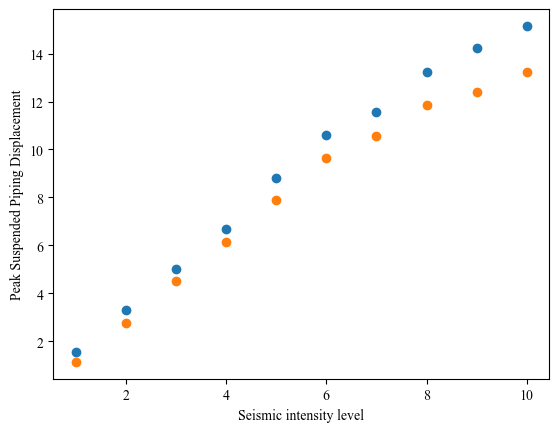

In [11]:
im = [1,2,3,4,5,6,7,8,9,10]
plt.scatter(im,Dxm)
plt.scatter(im,DxmS*1*1)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'Peak Suspended Piping Displacement')

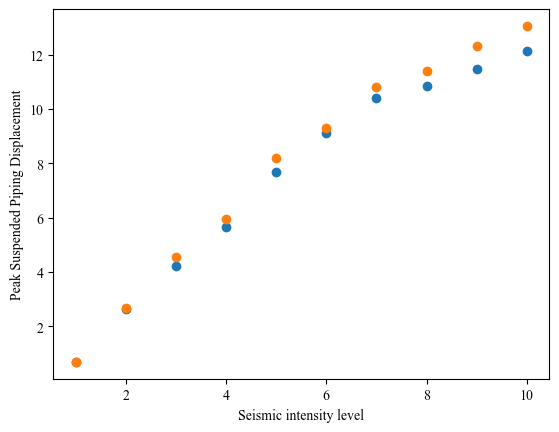

In [12]:
#plt.scatter(im,Dxm)
plt.scatter(im,Dym)
plt.scatter(im,DymS*1.05*1.04)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'MRE')

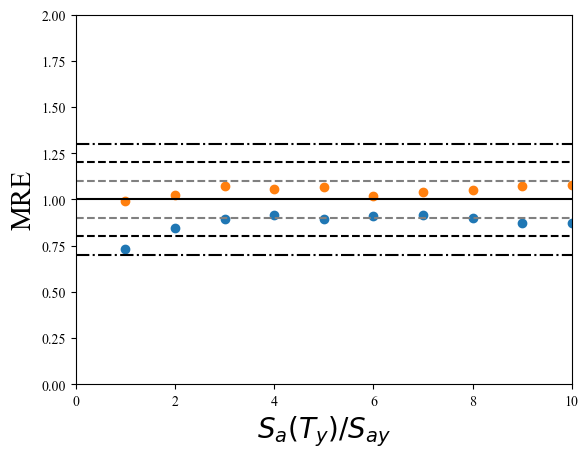

In [13]:
plt.scatter(im,(DxmS*1*1)/Dxm)
plt.scatter(im,(DymS*1.05*1.04)/Dym)

plt.plot((0,10),(1.1,1.1),color='grey',ls='--')
plt.plot((0,10),(0.9,0.9),color='grey',ls='--')

plt.plot((0,10),(1.2,1.2),color='k',ls='--')
plt.plot((0,10),(0.8,0.8),color='k',ls='--')

plt.plot((0,10),(1.3,1.3),color='k',ls='-.')
plt.plot((0,10),(0.7,0.7),color='k',ls='-.')

plt.plot((0,10),(1,1),color='k')
plt.ylim(0,2)
plt.xlim(0,10)
plt.xlabel(r'$S_{a}(T_y)/S_{ay}$',fontsize=20)
plt.ylabel(r'MRE',fontsize=20)

In [14]:
DispShapeX = np.load(model+"DispShapeX.npy")
DispShapeY = np.load(model+"DispShapeY.npy")

In [15]:
def DispShapeStat(DispShapeX,DispShapeY):
    tol = 0
    mask_rowsX = np.any(DispShapeX > tol, axis=(1))
    mask_rowsY = np.any(DispShapeY > tol, axis=(1))
    
    DispShapeX_no_zero = DispShapeX[mask_rowsX, :]
    DispShapeY_no_zero = DispShapeY[mask_rowsY, :]
    
    DSXm = DispShapeX_no_zero.mean(axis=0)
    DSYm = DispShapeY_no_zero.mean(axis=0)
    
    DSXs = DispShapeX_no_zero.std(axis=0)
    DSYs = DispShapeY_no_zero.std(axis=0)

    return DSXm,DSYm,DSXs,DSYs

In [16]:
DSXm = np.zeros((70,10))
DSYm = np.zeros((70,10))

DSXs = np.zeros((70,10))
DSYs = np.zeros((70,10))

for i in range(10):
    DSXm[:,i],DSYm[:,i],DSXs[:,i],DSYs[:,i] = DispShapeStat(DispShapeX[:,:,i],DispShapeY[:,:,i])

In [17]:
POy = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M30y.txt')
POx = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M30x.txt')

In [18]:
Vbx_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM30x_SDOF/VbaseC.out')
Dx_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM30x_SDOF/DispC.out')

In [19]:
Vby_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM30y_SDOF/VbaseC.out')
Dy_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM30y_SDOF/DispC.out')

In [20]:
Fx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM30_biron/ReactionsX.out')

Vbx_3D = np.zeros(len(Fx_3D[:,0]))
for i in range(len(Vbx_3D)):
    Vbx_3D[i] = -1*np.sum(Fx_3D[i,1:])

Dx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM30_biron/PipeNodeDispX.out')

Dx3D_eq = np.zeros(len(Dx_3D[:,0]))
for i in range(len(Dx3D_eq)):
    Dx3D_eq[i] = np.sum(Dx_3D[i,1:]**2)/np.sum(Dx_3D[i,1:])


In [21]:
Fy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM30_biron/ReactionsY.out')

Vby_3D = np.zeros(len(Fy_3D[:,0]))
for i in range(len(Vby_3D)):
    Vby_3D[i] = -1*np.sum(Fy_3D[i,1:])

Dy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM30_biron/PipeNodeDispY.out')

Dy3D_eq = np.zeros(len(Dy_3D[:,0]))
for i in range(len(Dy3D_eq)):
    Dy3D_eq[i] = np.sum(Dy_3D[i,1:]**2)/np.sum(Dy_3D[i,1:])

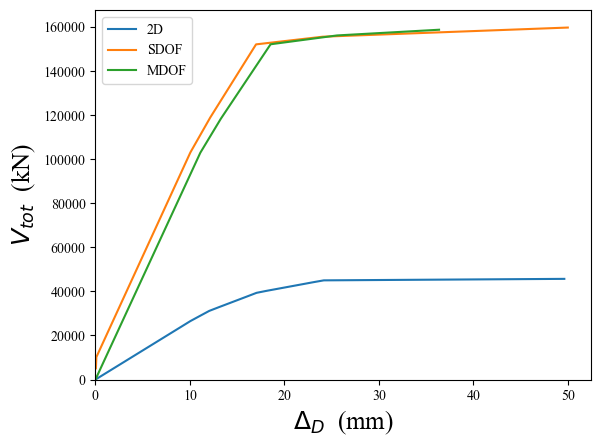

In [22]:
plt.plot(POx[:,5],POx[:,3],label='2D') #subassembly only 
plt.plot(Dx_SDOF,Vbx_SDOF,label='SDOF')
plt.plot(Dx3D_eq,Vbx_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

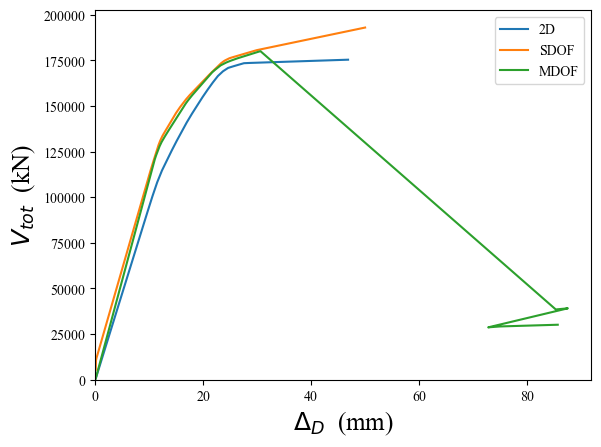

In [23]:
plt.plot(POy[:,5],POy[:,3],label='2D')
plt.plot(Dy_SDOF,Vby_SDOF,label='SDOF')
plt.plot(Dy3D_eq,Vby_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

In [24]:
im =8

In [25]:
Dstaticx = np.flip(POx[10,6:11])

In [26]:
Dstaticy = POy[:,6:31]

In [27]:
x0m = np.zeros(25)
y0m = np.zeros(25)

x0m[0] = -1.05
x0m[2] = 1.05
x0m[3] = 2.0
x0m[4] = 2.35
x0m[5] = 4.25
x0m[6] = 5.0
x0m[7] = 7.05
x0m[8] = 8.0
x0m[9] = 11.0
x0m[10] = 11.55
x0m[11] = 14
x0m[12] = 14.25
x0m[13] = 17.0
x0m[14] = 18.35
x0m[15] = 19.15
x0m[16] = 20.0
x0m[17] = 20.95
x0m[18] = 22.95
x0m[19] = 23.125
x0m[20] = 25.55
x0m[21] = 26
x0m[22] = 29
x0m[23] = 30.45
x0m[24] = 30.95

In [28]:
x0b1 = np.zeros(4)
y0b1 = np.zeros(4)

for i in range(len(x0b1)):
    x0b1[i] = 1.05

y0b1[0] = 0
y0b1[1] = 1.5
y0b1[2] = 4.5
y0b1[3] = 5.0

x0b2 = np.zeros(4)
y0b2 = np.zeros(4)

for i in range(len(x0b2)):
    x0b2[i] = 4.25

y0b2[0] = 0
y0b2[1] = 1.5
y0b2[2] = 4.5
y0b2[3] = 5.0

x0b3 = np.zeros(4)
y0b3 = np.zeros(4)

for i in range(len(x0b3)):
    x0b3[i] = 7.05

y0b3[0] = 0
y0b3[1] = 1.5
y0b3[2] = 4.5
y0b3[3] = 5.0

x0b4 = np.zeros(4)
y0b4 = np.zeros(4)

for i in range(len(x0b4)):
    x0b4[i] = 11.55

y0b4[0] = 0
y0b4[1] = 1.5
y0b4[2] = 4.5
y0b4[3] = 5.0

x0b5 = np.zeros(4)
y0b5 = np.zeros(4)

for i in range(len(x0b5)):
    x0b5[i] = 14.25

y0b5[0] = 0
y0b5[1] = 1.5
y0b5[2] = 4.5
y0b5[3] = 5.0

x0b6 = np.zeros(4)
y0b6 = np.zeros(4)

for i in range(len(x0b6)):
    x0b6[i] = 18.35

y0b6[0] = 0
y0b6[1] = 1.5
y0b6[2] = 4.5
y0b6[3] = 5.0

x0b7 = np.zeros(4)
y0b7 = np.zeros(4)

for i in range(len(x0b7)):
    x0b7[i] = 20.95

y0b7[0] = 0
y0b7[1] = 1.5
y0b7[2] = 4.5
y0b7[3] = 5.0

x0b8 = np.zeros(4)
y0b8 = np.zeros(4)

for i in range(len(x0b8)):
    x0b8[i] = 25.55

y0b8[0] = 0
y0b8[1] = 1.5
y0b8[2] = 4.5
y0b8[3] = 5.0

x0b9 = np.zeros(4)
y0b9 = np.zeros(4)

for i in range(len(x0b9)):
    x0b9[i] = 30.45

y0b9[0] = 0
y0b9[1] = 1.5
y0b9[2] = 4.5
y0b9[3] = 5.0

In [29]:
x0b10 = np.zeros(4)
y0b10 = np.zeros(4)

for i in range(len(x0b10)):
    x0b10[i] = 2.35

y0b10[3] = 0
y0b10[2] = -1.5
y0b10[1] = -4.5
y0b10[0] = -5.0

x0b11 = np.zeros(4)
y0b11 = np.zeros(4)

for i in range(len(x0b11)):
    x0b11[i] = 7.05

y0b11[3] = 0
y0b11[2] = -1.5
y0b11[1] = -4.5
y0b11[0] = -5.0

x0b12 = np.zeros(4)
y0b12 = np.zeros(4)

for i in range(len(x0b12)):
    x0b12[i] = 11.55

y0b12[3] = 0
y0b12[2] = -1.5
y0b12[1] = -4.5
y0b12[0] = -5.0

x0b13 = np.zeros(4)
y0b13 = np.zeros(4)

for i in range(len(x0b13)):
    x0b13[i] = 19.15

y0b13[3] = 0
y0b13[2] = -1.5
y0b13[1] = -4.5
y0b13[0] = -5.0

x0b14 = np.zeros(4)
y0b14 = np.zeros(4)

for i in range(len(x0b14)):
    x0b14[i] = 22.95

y0b14[3] = 0
y0b14[2] = -1.5
y0b14[1] = -4.5
y0b14[0] = -5.0

x0b15 = np.zeros(4)
y0b15 = np.zeros(4)

for i in range(len(x0b15)):
    x0b15[i] = 30.95

y0b15[3] = 0
y0b15[2] = -1.5
y0b15[1] = -4.5
y0b15[0] = -5.0

In [30]:
DSXML = DSXm[:25,im]
DSXBL1 = DSXm[25:28,im]
DSXBL2 = DSXm[28:31,im]
DSXBL3 = DSXm[31:34,im]
DSXBL4 = DSXm[34:37,im]
DSXBL5 = DSXm[37:40,im]
DSXBL6 = DSXm[40:43,im]
DSXBL7 = DSXm[43:46,im]
DSXBL8 = DSXm[46:49,im]
DSXBL9 = DSXm[49:52,im]
DSXBL10 = DSXm[52:55,im]
DSXBL11 = DSXm[55:58,im]
DSXBL12 = DSXm[58:61,im]
DSXBL13 = DSXm[61:64,im]
DSXBL14 = DSXm[64:67,im]
DSXBL15 = DSXm[67:70,im]

In [31]:
DSXMLs = DSXs[:25,im]
DSXBL1s = DSXs[25:28,im]
DSXBL2s = DSXs[28:31,im]
DSXBL3s = DSXs[31:34,im]
DSXBL4s = DSXs[34:37,im]
DSXBL5s = DSXs[37:40,im]
DSXBL6s = DSXs[40:43,im]
DSXBL7s = DSXs[43:46,im]
DSXBL8s = DSXs[46:49,im]
DSXBL9s = DSXs[49:52,im]
DSXBL10s = DSXs[52:55,im]
DSXBL11s = DSXs[55:58,im]
DSXBL12s = DSXs[58:61,im]
DSXBL13s = DSXs[61:64,im]
DSXBL14s = DSXs[64:67,im]
DSXBL15s = DSXs[67:70,im]

In [32]:
DSXBL1 = np.insert(DSXBL1,0,DSXm[2,im])
DSXBL2 = np.insert(DSXBL2,0,DSXm[5,im])
DSXBL3 = np.insert(DSXBL3,0,DSXm[7,im])
DSXBL4 = np.insert(DSXBL4,0,DSXm[10,im])
DSXBL5 = np.insert(DSXBL5,0,DSXm[12,im])
DSXBL6 = np.insert(DSXBL6,0,DSXm[14,im])
DSXBL7 = np.insert(DSXBL7,0,DSXm[17,im])
DSXBL8 = np.insert(DSXBL8,0,DSXm[20,im])
DSXBL9 = np.insert(DSXBL9,0,DSXm[23,im])
DSXBL10 = np.insert(DSXBL10,2,DSXm[4,im])
DSXBL11 = np.insert(DSXBL11,2,DSXm[7,im])
DSXBL12 = np.insert(DSXBL12,2,DSXm[10,im])
DSXBL13 = np.insert(DSXBL13,2,DSXm[15,im])
DSXBL14 = np.insert(DSXBL14,2,DSXm[18,im])
DSXBL15 = np.insert(DSXBL15,2,DSXm[23,im])

In [33]:
DSXBL1s = np.insert(DSXBL1s,0,DSXs[2,im])
DSXBL2s = np.insert(DSXBL2s,0,DSXs[5,im])
DSXBL3s = np.insert(DSXBL3s,0,DSXs[7,im])
DSXBL4s = np.insert(DSXBL4s,0,DSXs[10,im])
DSXBL5s = np.insert(DSXBL5s,0,DSXs[12,im])
DSXBL6s = np.insert(DSXBL6s,0,DSXs[14,im])
DSXBL7s = np.insert(DSXBL7s,0,DSXs[17,im])
DSXBL8s = np.insert(DSXBL8s,0,DSXs[20,im])
DSXBL9s = np.insert(DSXBL9s,0,DSXs[23,im])
DSXBL10s = np.insert(DSXBL10s,2,DSXs[4,im])
DSXBL11s = np.insert(DSXBL11s,2,DSXs[7,im])
DSXBL12s = np.insert(DSXBL12s,2,DSXs[10,im])
DSXBL13s = np.insert(DSXBL13s,2,DSXs[15,im])
DSXBL14s = np.insert(DSXBL14s,2,DSXs[18,im])
DSXBL15s = np.insert(DSXBL15s,2,DSXs[23,im])

In [34]:
DSYML = DSYm[:25,im]
DSYBL1 = DSYm[25:28,im]
DSYBL2 = DSYm[28:31,im]
DSYBL3 = DSYm[31:34,im]
DSYBL4 = DSYm[34:37,im]
DSYBL5 = DSYm[37:40,im]
DSYBL6 = DSYm[40:43,im]
DSYBL7 = DSYm[43:46,im]
DSYBL8 = DSYm[46:49,im]
DSYBL9 = DSYm[49:52,im]
DSYBL10 = DSYm[52:55,im]
DSYBL11 = DSYm[55:58,im]
DSYBL12 = DSYm[58:61,im]
DSYBL13 = DSYm[61:64,im]
DSYBL14 = DSYm[64:67,im]
DSYBL15 = DSYm[67:70,im]

In [35]:
DSYMLs = DSYs[:25,im]
DSYBL1s = DSYs[25:28,im]
DSYBL2s = DSYs[28:31,im]
DSYBL3s = DSYs[31:34,im]
DSYBL4s = DSYs[34:37,im]
DSYBL5s = DSYs[37:40,im]
DSYBL6s = DSYs[40:43,im]
DSYBL7s = DSYs[43:46,im]
DSYBL8s = DSYs[46:49,im]
DSYBL9s = DSYs[49:52,im]
DSYBL10s = DSYs[52:55,im]
DSYBL11s = DSYs[55:58,im]
DSYBL12s = DSYs[58:61,im]
DSYBL13s = DSYs[61:64,im]
DSYBL14s = DSYs[64:67,im]
DSYBL15s = DSYs[67:70,im]

In [36]:
DSYBL1 = np.insert(DSYBL1,0,DSYm[2,im])
DSYBL2 = np.insert(DSYBL2,0,DSYm[5,im])
DSYBL3 = np.insert(DSYBL3,0,DSYm[7,im])
DSYBL4 = np.insert(DSYBL4,0,DSYm[10,im])
DSYBL5 = np.insert(DSYBL5,0,DSYm[12,im])
DSYBL6 = np.insert(DSYBL6,0,DSYm[14,im])
DSYBL7 = np.insert(DSYBL7,0,DSYm[17,im])
DSYBL8 = np.insert(DSYBL8,0,DSYm[20,im])
DSYBL9 = np.insert(DSYBL9,0,DSYm[23,im])
DSYBL10 = np.insert(DSYBL10,2,DSYm[4,im])
DSYBL11 = np.insert(DSYBL11,2,DSYm[7,im])
DSYBL12 = np.insert(DSYBL12,2,DSYm[10,im])
DSYBL13 = np.insert(DSYBL13,2,DSYm[15,im])
DSYBL14 = np.insert(DSYBL14,2,DSYm[18,im])
DSYBL15 = np.insert(DSYBL15,2,DSYm[23,im])

In [37]:
DSYBL1s = np.insert(DSYBL1s,0,DSYs[2,im])
DSYBL2s = np.insert(DSYBL2s,0,DSYs[5,im])
DSYBL3s = np.insert(DSYBL3s,0,DSYs[7,im])
DSYBL4s = np.insert(DSYBL4s,0,DSYs[10,im])
DSYBL5s = np.insert(DSYBL5s,0,DSYs[12,im])
DSYBL6s = np.insert(DSYBL6s,0,DSYs[14,im])
DSYBL7s = np.insert(DSYBL7s,0,DSYs[17,im])
DSYBL8s = np.insert(DSYBL8s,0,DSYs[20,im])
DSYBL9s = np.insert(DSYBL9s,0,DSYs[23,im])
DSYBL10s = np.insert(DSYBL10s,2,DSYs[4,im])
DSYBL11s = np.insert(DSYBL11s,2,DSYs[7,im])
DSYBL12s = np.insert(DSYBL12s,2,DSYs[10,im])
DSYBL13s = np.insert(DSYBL13s,2,DSYs[15,im])
DSYBL14s = np.insert(DSYBL14s,2,DSYs[18,im])
DSYBL15s = np.insert(DSYBL15s,2,DSYs[23,im])

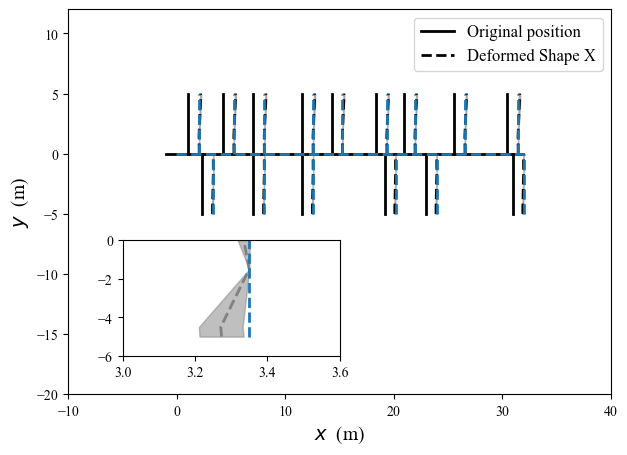

In [39]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))


ax.plot(x0m,y0m, color='k',lw=2,label='Original position')

ax.plot(x0b1,y0b1, color='k',lw=2)
ax.plot(x0b2,y0b2, color='k',lw=2)
ax.plot(x0b3,y0b3, color='k',lw=2)
ax.plot(x0b4,y0b4, color='k',lw=2)
ax.plot(x0b5,y0b5, color='k',lw=2)
ax.plot(x0b6,y0b6, color='k',lw=2)
ax.plot(x0b7,y0b7, color='k',lw=2)
ax.plot(x0b8,y0b8, color='k',lw=2)
ax.plot(x0b9,y0b9, color='k',lw=2)

ax.plot(x0b10,y0b10, color='k',lw=2)
ax.plot(x0b11,y0b11, color='k',lw=2)
ax.plot(x0b12,y0b12, color='k',lw=2)
ax.plot(x0b13,y0b13, color='k',lw=2)
ax.plot(x0b14,y0b14, color='k',lw=2)
ax.plot(x0b15,y0b15, color='k',lw=2)

ampx = 1

ax.plot(x0m+ampx*DSXML,y0m, color='k',ls= '--',lw=2,label='Deformed Shape X')
ax.plot(x0b1+ampx*DSXBL1,y0b1, color='k',lw=2, ls='--')
ax.plot(x0b2+ampx*DSXBL2,y0b2, color='k',lw=2, ls='--')
ax.plot(x0b3+ampx*DSXBL3,y0b3, color='k',lw=2, ls='--')
ax.plot(x0b4+ampx*DSXBL4,y0b4, color='k',lw=2, ls='--')
ax.plot(x0b5+ampx*DSXBL5,y0b5, color='k',lw=2, ls='--')
ax.plot(x0b6+ampx*DSXBL6,y0b6, color='k',lw=2, ls='--')
ax.plot(x0b7+ampx*DSXBL7,y0b7, color='k',lw=2, ls='--')
ax.plot(x0b8+ampx*DSXBL8,y0b8, color='k',lw=2, ls='--')
ax.plot(x0b9+ampx*DSXBL9,y0b9, color='k',lw=2, ls='--')

ax.fill_betweenx(y0b1,x0b1+ampx*(DSXBL1+2*DSXBL1s),x0b1+ampx*(DSXBL1-2*DSXBL1s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b2,x0b2+ampx*(DSXBL2+2*DSXBL2s),x0b2+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b3,x0b3+ampx*(DSXBL3+2*DSXBL3s),x0b3+ampx*(DSXBL3-2*DSXBL3s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b4,x0b4+ampx*(DSXBL4+2*DSXBL4s),x0b4+ampx*(DSXBL4-2*DSXBL4s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b5,x0b5+ampx*(DSXBL5+2*DSXBL5s),x0b5+ampx*(DSXBL5-2*DSXBL5s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b6,x0b6+ampx*(DSXBL6+2*DSXBL6s),x0b6+ampx*(DSXBL6-2*DSXBL6s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b7,x0b7+ampx*(DSXBL7+2*DSXBL7s),x0b7+ampx*(DSXBL7-2*DSXBL7s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b8,x0b8+ampx*(DSXBL8+2*DSXBL8s),x0b8+ampx*(DSXBL8-2*DSXBL8s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b9,x0b9+ampx*(DSXBL9+2*DSXBL9s),x0b9+ampx*(DSXBL9-2*DSXBL9s),color='grey',alpha=0.5)


ax.plot(x0b10+ampx*DSXBL10,y0b10, color='k',lw=2, ls='--')
ax.plot(x0b11+ampx*DSXBL11,y0b11, color='k',lw=2, ls='--')
ax.plot(x0b12+ampx*DSXBL12,y0b12, color='k',lw=2, ls='--')
ax.plot(x0b13+ampx*DSXBL13,y0b13, color='k',lw=2, ls='--')
ax.plot(x0b14+ampx*DSXBL14,y0b14, color='k',lw=2, ls='--')
ax.plot(x0b15+ampx*DSXBL15,y0b15, color='k',lw=2, ls='--')

ax.fill_betweenx(y0b10,x0b10+ampx*(DSXBL10+2*DSXBL10s),x0b10+ampx*(DSXBL10-2*DSXBL10s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b11,x0b11+ampx*(DSXBL11+2*DSXBL11s),x0b11+ampx*(DSXBL11-2*DSXBL11s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b12,x0b12+ampx*(DSXBL12+2*DSXBL12s),x0b12+ampx*(DSXBL12-2*DSXBL12s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b13,x0b13+ampx*(DSXBL13+2*DSXBL13s),x0b13+ampx*(DSXBL13-2*DSXBL13s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b14,x0b14+ampx*(DSXBL14+2*DSXBL14s),x0b14+ampx*(DSXBL14-2*DSXBL14s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b15,x0b15+ampx*(DSXBL15+2*DSXBL15s),x0b15+ampx*(DSXBL15-2*DSXBL15s),color='grey',alpha=0.5)

ax.plot(x0m+ampx*np.ones(len(x0m)),y0m, color='C0',ls= '--',lw=2)
ax.plot(x0b1+ampx*np.ones(len(x0b1)),y0b1, color='C0',lw=2, ls='--')
ax.plot(x0b2+ampx*np.ones(len(x0b1)), y0b2,color='C0',lw=2, ls='--')
ax.plot(x0b3+ampx*np.ones(len(x0b1)),y0b3, color='C0',lw=2, ls='--')
ax.plot(x0b4+ampx*np.ones(len(x0b1)),y0b4, color='C0',lw=2, ls='--')
ax.plot(x0b5+ampx*np.ones(len(x0b1)),y0b5, color='C0',lw=2, ls='--')
ax.plot(x0b6+ampx*np.ones(len(x0b1)),y0b6, color='C0',lw=2, ls='--')
ax.plot(x0b7+ampx*np.ones(len(x0b1)),y0b7, color='C0',lw=2, ls='--')
ax.plot(x0b8+ampx*np.ones(len(x0b1)),y0b8, color='C0',lw=2, ls='--')
ax.plot(x0b9+ampx*np.ones(len(x0b1)),y0b9, color='C0',lw=2, ls='--')

ax.plot(x0b10+ampx*np.ones(len(x0b1)),y0b10, color='C0',lw=2, ls='--')
ax.plot(x0b11+ampx*np.ones(len(x0b1)),y0b11, color='C0',lw=2, ls='--')
ax.plot(x0b12+ampx*np.ones(len(x0b1)),y0b12, color='C0',lw=2, ls='--')
ax.plot(x0b13+ampx*np.ones(len(x0b1)),y0b13, color='C0',lw=2, ls='--')
ax.plot(x0b14+ampx*np.ones(len(x0b1)),y0b14, color='C0',lw=2, ls='--')
ax.plot(x0b15+ampx*np.ones(len(x0b1)),y0b15, color='C0',lw=2, ls='--')

axins1 = ax.inset_axes([0.1, 0.1, 0.4, 0.3],xlim=(3,3.6), ylim=(-6, 0))
axins1.plot(x0b10+ampx*DSXBL10,y0b10, color='grey',lw=2, ls='--')
axins1.plot(x0b10+ampx*np.ones(len(x0b1)),y0b10, color='C0',lw=2, ls='--')
axins1.fill_betweenx(y0b10,x0b10+ampx*(DSXBL10+2*DSXBL10s),x0b10+ampx*(DSXBL10-2*DSXBL10s),color='grey',alpha=0.5)



ax.set_xlim(-10, 40)
ax.set_ylim(-20,12)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

ax.legend(fontsize=12)

In [40]:
Gx_NLTH, mx_NLTH = Gamma(DSXm[:,5])
Gx_NLTH

0.9905774866232889

In [41]:
mx_mod_NLTH = mx_NLTH/np.sum(m)

In [42]:
mx_NLTH

12.870207238918377

In [43]:
Gx_static = POx[10,1]
Gx_static

0.991

In [44]:
mx_static = POx[10,2]
mx_static

11.851

In [45]:
mx_mod_static = POx[10,4]

In [46]:
mx_mod_static*np.sum(m)

12.947000000000001

In [47]:
abs(Gx_static-Gx_NLTH)/Gx_NLTH

0.00042653238380304916

In [48]:
abs(mx_mod_static-mx_mod_NLTH)/mx_NLTH

0.0004608563701288581

In [49]:
x_ortho_user = np.array([1050,4250,7050,11550,14250,18350,20950,25550,30450,2350,7050,11550,19150,22950,30950])

In [50]:
#0,2,1,0,5,1,0,8,11,0,1,14,0,17,0,1,20,0,1,23,0,26,0,29,1
#5,17,29
#4,13,23
#0,2,3,5,6,9,10,12,14,15,17,18,20,22,24

In [51]:
Dstaticy[10,:]

array([0.769, 0.769, 0.77 , 0.779, 0.779, 0.915, 0.915, 0.947, 0.923,
       0.926, 0.926, 0.973, 0.972, 0.914, 0.953, 0.98 , 0.993, 1.005,
       1.044, 1.044, 1.103, 1.106, 0.947, 0.982, 1.   ])

In [52]:
Dstaticy[10,23]

0.982

In [53]:
np.sum(abs(DSYML-Dstaticy[10,:]/Dstaticy[10,0])/DSYML)/(4*15+len(DSYML))

0.03952483704188268

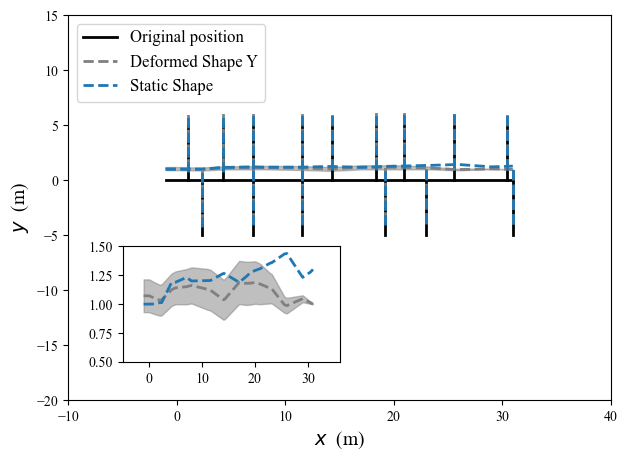

In [54]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))

ax.plot(x0m,y0m, color='k',lw=2,label='Original position')

ax.plot(x0b1,y0b1, color='k',lw=2)
ax.plot(x0b2,y0b2, color='k',lw=2)
ax.plot(x0b3,y0b3, color='k',lw=2)
ax.plot(x0b4,y0b4, color='k',lw=2)
ax.plot(x0b5,y0b5, color='k',lw=2)
ax.plot(x0b6,y0b6, color='k',lw=2)
ax.plot(x0b7,y0b7, color='k',lw=2)
ax.plot(x0b8,y0b8, color='k',lw=2)
ax.plot(x0b9,y0b9, color='k',lw=2)

ax.plot(x0b10,y0b10, color='k',lw=2)
ax.plot(x0b11,y0b11, color='k',lw=2)
ax.plot(x0b12,y0b12, color='k',lw=2)
ax.plot(x0b13,y0b13, color='k',lw=2)
ax.plot(x0b14,y0b14, color='k',lw=2)
ax.plot(x0b15,y0b15, color='k',lw=2)

ampy = 1

ax.plot(x0m,y0m+ampy*DSYML, color='grey',ls= '--',lw=2,label='Deformed Shape Y')
ax.plot(x0m,y0m+ampy*Dstaticy[10,:]/Dstaticy[10,0], color='C0',ls= '--',lw=2,label='Static Shape')

ax.fill_between(x0m,y0m+ampx*(DSYML+2*DSYMLs),y0m+ampx*(DSYML-2*DSYMLs),color='grey',alpha=0.5)

ax.plot(x0b1,y0b1+ampy*DSYBL1, color='grey',lw=2, ls='--')
ax.plot(x0b2,y0b2+ampy*DSYBL2, color='grey',lw=2, ls='--')
ax.plot(x0b3,y0b3+ampy*DSYBL3, color='grey',lw=2, ls='--')
ax.plot(x0b4,y0b4+ampy*DSYBL4, color='grey',lw=2, ls='--')
ax.plot(x0b5,y0b5+ampy*DSYBL5, color='grey',lw=2, ls='--')
ax.plot(x0b6,y0b6+ampy*DSYBL6, color='grey',lw=2, ls='--')
ax.plot(x0b7,y0b7+ampy*DSYBL7, color='grey',lw=2, ls='--')
ax.plot(x0b8,y0b8+ampy*DSYBL8, color='grey',lw=2, ls='--')
ax.plot(x0b9,y0b9+ampy*DSYBL9, color='grey',lw=2, ls='--')

ax.plot(x0b1,y0b1+ampy*np.ones(len(y0b1))*Dstaticy[10,0], color='C0',lw=2, ls='--')
ax.plot(x0b2,y0b2+ampy*np.ones(len(y0b1))*Dstaticy[10,3], color='C0',lw=2, ls='--')
ax.plot(x0b3,y0b3+ampy*np.ones(len(y0b1))*Dstaticy[10,6], color='C0',lw=2, ls='--')
ax.plot(x0b4,y0b4+ampy*np.ones(len(y0b1))*Dstaticy[10,9], color='C0',lw=2, ls='--')
ax.plot(x0b5,y0b5+ampy*np.ones(len(y0b1))*Dstaticy[10,12], color='C0',lw=2, ls='--')
ax.plot(x0b6,y0b6+ampy*np.ones(len(y0b1))*Dstaticy[10,14], color='C0',lw=2, ls='--')
ax.plot(x0b7,y0b7+ampy*np.ones(len(y0b1))*Dstaticy[10,17], color='C0',lw=2, ls='--')
ax.plot(x0b8,y0b8+ampy*np.ones(len(y0b1))*Dstaticy[10,21], color='C0',lw=2, ls='--')
ax.plot(x0b9,y0b9+ampy*np.ones(len(y0b1))*Dstaticy[10,23], color='C0',lw=2, ls='--')

ax.plot(x0b10,y0b10+ampy*DSYBL10, color='grey',lw=2, ls='--')
ax.plot(x0b11,y0b11+ampy*DSYBL11, color='grey',lw=2, ls='--')
ax.plot(x0b12,y0b12+ampy*DSYBL12, color='grey',lw=2, ls='--')
ax.plot(x0b13,y0b13+ampy*DSYBL13, color='grey',lw=2, ls='--')
ax.plot(x0b14,y0b14+ampy*DSYBL14, color='grey',lw=2, ls='--')
ax.plot(x0b15,y0b15+ampy*DSYBL15, color='grey',lw=2, ls='--')

ax.plot(x0b10,y0b10+ampy*np.ones(len(y0b1))*Dstaticy[10,2], color='C0',lw=2, ls='--')
ax.plot(x0b11,y0b11+ampy*np.ones(len(y0b1))*Dstaticy[10,5], color='C0',lw=2, ls='--')
ax.plot(x0b12,y0b12+ampy*np.ones(len(y0b1))*Dstaticy[10,10], color='C0',lw=2, ls='--')
ax.plot(x0b13,y0b13+ampy*np.ones(len(y0b1))*Dstaticy[10,15], color='C0',lw=2, ls='--')
ax.plot(x0b14,y0b14+ampy*np.ones(len(y0b1))*Dstaticy[10,18], color='C0',lw=2, ls='--')
ax.plot(x0b15,y0b15+ampy*np.ones(len(y0b1))*Dstaticy[10,24], color='C0',lw=2, ls='--')

axins1 = ax.inset_axes([0.1, 0.1, 0.4, 0.3],xlim=(-5,36), ylim=(0.5, 1.5))
axins1.plot(x0m,y0m+ampy*DSYML, color='grey',ls= '--',lw=2,label='Deformed Shape Y')
axins1.plot(x0m,y0m+ampy*Dstaticy[10,:]/Dstaticy[10,0], color='C0',ls= '--',lw=2,label='Static Shape')
axins1.fill_between(x0m,y0m+ampx*(DSYML+2*DSYMLs),y0m+ampx*(DSYML-2*DSYMLs),color='grey',alpha=0.5)

ax.set_xlim(-10, 40)
ax.set_ylim(-20,15)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

ax.legend(fontsize=12,loc=2)

In [131]:
Gy_NLTH, my_NLTH = Gamma(DSYm[:,5])
Gy_NLTH

0.8946788758364365

In [132]:
modal_my_NLTH = my_NLTH/np.sum(m)

In [133]:
modal_my_NLTH

0.9957434435392123

In [134]:
Gy_static = POy[10,1]
Gy_static

1.055

In [135]:
my_static = POy[10,2]
my_static

14.387

In [136]:
modal_my_static = POy[10,4]
modal_my_static*np.sum(m)

12.817530000000001

In [137]:
abs(Gy_static-Gy_NLTH)/Gy_NLTH

0.17919404212341444

In [138]:
abs(modal_my_NLTH-modal_my_static)/my_NLTH

0.00044550825187533234

In [139]:
np.max(Dstaticy[10,:])

1.106

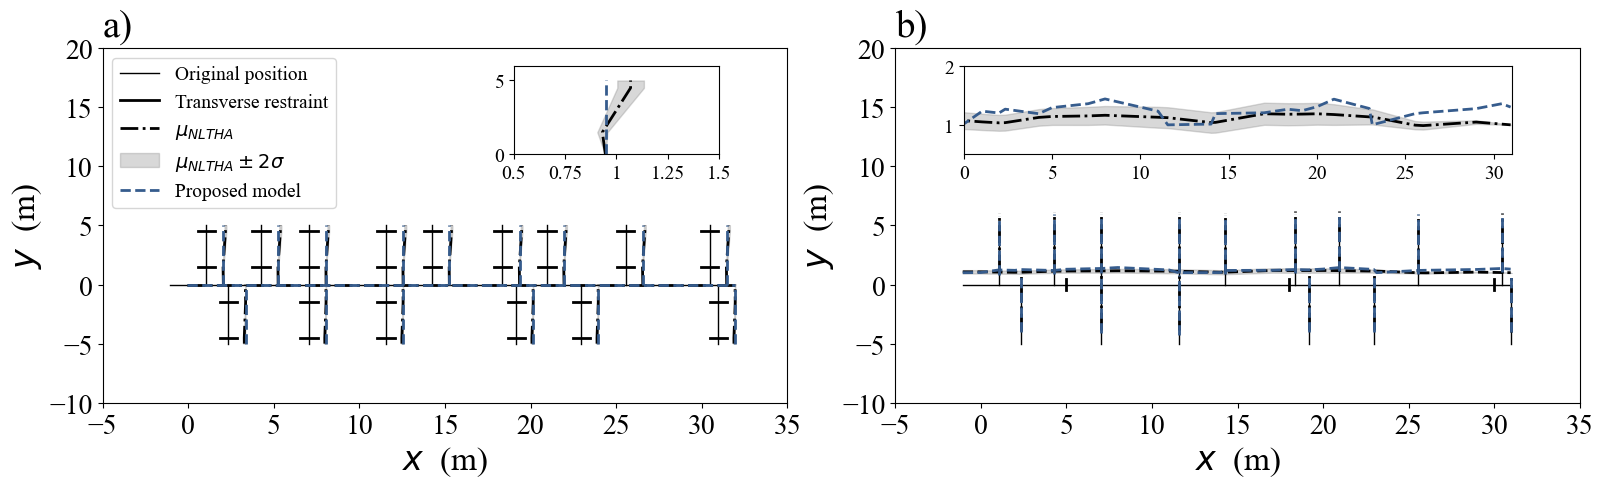

In [144]:
fig, ax = plt.subplots(ncols=2,figsize=(16,5))


ax[0].plot(x0m,y0m, color='k',lw=1,label='Original position')

ax[0].plot(x0b1,y0b1, color='k',lw=1)
ax[0].plot(x0b2,y0b2, color='k',lw=1)
ax[0].plot(x0b3,y0b3, color='k',lw=1)
ax[0].plot(x0b4,y0b4, color='k',lw=1)
ax[0].plot(x0b5,y0b5, color='k',lw=1)
ax[0].plot(x0b6,y0b6, color='k',lw=1)
ax[0].plot(x0b7,y0b7, color='k',lw=1)
ax[0].plot(x0b8,y0b8, color='k',lw=1)
ax[0].plot(x0b9,y0b9, color='k',lw=1)

ax[0].plot(x0b10,y0b10, color='k',lw=1)
ax[0].plot(x0b11,y0b11, color='k',lw=1)
ax[0].plot(x0b12,y0b12, color='k',lw=1)
ax[0].plot(x0b13,y0b13, color='k',lw=1)
ax[0].plot(x0b14,y0b14, color='k',lw=1)
ax[0].plot(x0b15,y0b15, color='k',lw=1)

ax[0].plot((0.55,1.55),(1.5,1.5),color='k',lw=2,label='Transverse restraint')
ax[0].plot((0.55,1.55),(4.5,4.5),color='k',lw=2)

ax[0].plot((3.75,4.75),(1.5,1.5),color='k',lw=2)
ax[0].plot((3.75,4.75),(4.5,4.5),color='k',lw=2)

ax[0].plot((6.55,7.55),(1.5,1.5),color='k',lw=2)
ax[0].plot((6.55,7.55),(4.5,4.5),color='k',lw=2)

ax[0].plot((11.05,12.05),(1.5,1.5),color='k',lw=2)
ax[0].plot((11.05,12.05),(4.5,4.5),color='k',lw=2)

ax[0].plot((13.75,14.75),(1.5,1.5),color='k',lw=2)
ax[0].plot((13.75,14.75),(4.5,4.5),color='k',lw=2)

ax[0].plot((17.85,18.85),(1.5,1.5),color='k',lw=2)
ax[0].plot((17.85,18.85),(4.5,4.5),color='k',lw=2)

ax[0].plot((20.45,21.45),(1.5,1.5),color='k',lw=2)
ax[0].plot((20.45,21.45),(4.5,4.5),color='k',lw=2)

ax[0].plot((25.05,26.05),(1.5,1.5),color='k',lw=2)
ax[0].plot((25.05,26.05),(4.5,4.5),color='k',lw=2)

ax[0].plot((29.95,30.95),(1.5,1.5),color='k',lw=2)
ax[0].plot((29.95,30.95),(4.5,4.5),color='k',lw=2)

ax[0].plot((1.85,2.85),(-1.5,-1.5),color='k',lw=2)
ax[0].plot((1.85,2.85),(-4.5,-4.5),color='k',lw=2)

ax[0].plot((6.55,7.55),(-1.5,-1.5),color='k',lw=2)
ax[0].plot((6.55,7.55),(-4.5,-4.5),color='k',lw=2)

ax[0].plot((11.05,12.05),(-1.5,-1.5),color='k',lw=2)
ax[0].plot((11.05,12.05),(-4.5,-4.5),color='k',lw=2)

ax[0].plot((18.65,19.65),(-1.5,-1.5),color='k',lw=2)
ax[0].plot((18.65,19.65),(-4.5,-4.5),color='k',lw=2)

ax[0].plot((22.45,23.45),(-1.5,-1.5),color='k',lw=2)
ax[0].plot((22.45,23.45),(-4.5,-4.5),color='k',lw=2)

ax[0].plot((30.45,31.45),(-1.5,-1.5),color='k',lw=2)
ax[0].plot((30.45,31.45),(-4.5,-4.5),color='k',lw=2)

ampx = 1

ax[0].plot(x0m+ampx*DSXML,y0m, color='k',ls= '-.',lw=2,label=r'$\mu_{NLTHA}$')
ax[0].plot(x0b1+ampx*DSXBL1,y0b1, color='k',lw=2, ls='-.')
ax[0].plot(x0b2+ampx*DSXBL2,y0b2, color='k',lw=2, ls='-.')
ax[0].plot(x0b3+ampx*DSXBL3,y0b3, color='k',lw=2, ls='-.')
ax[0].plot(x0b4+ampx*DSXBL4,y0b4, color='k',lw=2, ls='-.')
ax[0].plot(x0b5+ampx*DSXBL5,y0b5, color='k',lw=2, ls='-.')
ax[0].plot(x0b6+ampx*DSXBL6,y0b6, color='k',lw=2, ls='-.')
ax[0].plot(x0b7+ampx*DSXBL7,y0b7, color='k',lw=2, ls='-.')
ax[0].plot(x0b8+ampx*DSXBL8,y0b8, color='k',lw=2, ls='-.')
ax[0].plot(x0b9+ampx*DSXBL9,y0b9, color='k',lw=2, ls='-.')

ax[0].fill_betweenx(y0b1,x0b1+ampx*(DSXBL1+2*DSXBL1s),x0b1+ampx*(DSXBL1-2*DSXBL1s),color='grey',alpha=0.3,label=r'$\mu_{NLTHA} \pm 2\sigma$')
ax[0].fill_betweenx(y0b2,x0b2+ampx*(DSXBL2+2*DSXBL2s),x0b2+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b3,x0b3+ampx*(DSXBL3+2*DSXBL3s),x0b3+ampx*(DSXBL3-2*DSXBL3s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b4,x0b4+ampx*(DSXBL4+2*DSXBL4s),x0b4+ampx*(DSXBL4-2*DSXBL4s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b5,x0b5+ampx*(DSXBL5+2*DSXBL5s),x0b5+ampx*(DSXBL5-2*DSXBL5s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b6,x0b6+ampx*(DSXBL6+2*DSXBL6s),x0b6+ampx*(DSXBL6-2*DSXBL6s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b7,x0b7+ampx*(DSXBL7+2*DSXBL7s),x0b7+ampx*(DSXBL7-2*DSXBL7s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b8,x0b8+ampx*(DSXBL8+2*DSXBL8s),x0b8+ampx*(DSXBL8-2*DSXBL8s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b9,x0b9+ampx*(DSXBL9+2*DSXBL9s),x0b9+ampx*(DSXBL9-2*DSXBL9s),color='grey',alpha=0.3)


ax[0].plot(x0b10+ampx*DSXBL10,y0b10, color='k',lw=2, ls='-.')
ax[0].plot(x0b11+ampx*DSXBL11,y0b11, color='k',lw=2, ls='-.')
ax[0].plot(x0b12+ampx*DSXBL12,y0b12, color='k',lw=2, ls='-.')
ax[0].plot(x0b13+ampx*DSXBL13,y0b13, color='k',lw=2, ls='-.')
ax[0].plot(x0b14+ampx*DSXBL14,y0b14, color='k',lw=2, ls='-.')
ax[0].plot(x0b15+ampx*DSXBL15,y0b15, color='k',lw=2, ls='-.')

ax[0].fill_betweenx(y0b10,x0b10+ampx*(DSXBL10+2*DSXBL10s),x0b10+ampx*(DSXBL10-2*DSXBL10s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b11,x0b11+ampx*(DSXBL11+2*DSXBL11s),x0b11+ampx*(DSXBL11-2*DSXBL11s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b12,x0b12+ampx*(DSXBL12+2*DSXBL12s),x0b12+ampx*(DSXBL12-2*DSXBL12s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b13,x0b13+ampx*(DSXBL13+2*DSXBL13s),x0b13+ampx*(DSXBL13-2*DSXBL13s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b14,x0b14+ampx*(DSXBL14+2*DSXBL14s),x0b14+ampx*(DSXBL14-2*DSXBL14s),color='grey',alpha=0.3)
ax[0].fill_betweenx(y0b15,x0b15+ampx*(DSXBL15+2*DSXBL15s),x0b15+ampx*(DSXBL15-2*DSXBL15s),color='grey',alpha=0.3)

ax[0].plot(x0m+ampx*np.ones(len(x0m)),y0m, color='#365c8d',ls= '--',lw=2,label='Proposed model')
ax[0].plot(x0b1+ampx*np.ones(len(x0b1)),y0b1, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b2+ampx*np.ones(len(x0b1)), y0b2,color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b3+ampx*np.ones(len(x0b1)),y0b3, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b4+ampx*np.ones(len(x0b1)),y0b4, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b5+ampx*np.ones(len(x0b1)),y0b5, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b6+ampx*np.ones(len(x0b1)),y0b6, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b7+ampx*np.ones(len(x0b1)),y0b7, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b8+ampx*np.ones(len(x0b1)),y0b8, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b9+ampx*np.ones(len(x0b1)),y0b9, color='#365c8d',lw=2, ls='--')

ax[0].plot(x0b10+ampx*np.ones(len(x0b1)),y0b10, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b11+ampx*np.ones(len(x0b1)),y0b11, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b12+ampx*np.ones(len(x0b1)),y0b12, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b13+ampx*np.ones(len(x0b1)),y0b13, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b14+ampx*np.ones(len(x0b1)),y0b14, color='#365c8d',lw=2, ls='--')
ax[0].plot(x0b15+ampx*np.ones(len(x0b1)),y0b15, color='#365c8d',lw=2, ls='--')

axins1 = ax[0].inset_axes([0.6, 0.7, 0.3, 0.25],xlim=(31,32), ylim=(0,6))
axins1.plot(x0b9+ampx*DSXBL9,y0b9, color='k',lw=2, ls='-.')
axins1.plot(x0b9+ampx*np.ones(len(x0b9)),y0b9, color='#365c8d',lw=2, ls='--')
axins1.fill_betweenx(y0b9,x0b9+ampx*(DSXBL9+2*DSXBL9s),x0b9+ampx*(DSXBL9-2*DSXBL9s),color='grey',alpha=0.3)
axins1.set_xticks(ticks=[31,31.25,31.5,31.75,32],labels=[0.5,0.75,1,1.25,1.5])
axins1.tick_params(labelsize=14)

ax[0].text(-5,21,'a)',fontsize=28)
ax[0].set_xlim(-5, 35)
ax[0].set_ylim(-10,20)
ax[0].tick_params(labelsize=20)
ax[0].set_ylabel(r'$y$  (m)',fontsize=24)
ax[0].set_xlabel(r'$x$  (m)',fontsize=24)

ax[0].legend(fontsize=14,loc=2)


ax[1].plot(x0m,y0m, color='k',lw=1,label='Original position')

ax[1].plot(x0b1,y0b1, color='k',lw=1)
ax[1].plot(x0b2,y0b2, color='k',lw=1)
ax[1].plot(x0b3,y0b3, color='k',lw=1)
ax[1].plot(x0b4,y0b4, color='k',lw=1)
ax[1].plot(x0b5,y0b5, color='k',lw=1)
ax[1].plot(x0b6,y0b6, color='k',lw=1)
ax[1].plot(x0b7,y0b7, color='k',lw=1)
ax[1].plot(x0b8,y0b8, color='k',lw=1)
ax[1].plot(x0b9,y0b9, color='k',lw=1)

ax[1].plot(x0b10,y0b10, color='k',lw=1)
ax[1].plot(x0b11,y0b11, color='k',lw=1)
ax[1].plot(x0b12,y0b12, color='k',lw=1)
ax[1].plot(x0b13,y0b13, color='k',lw=1)
ax[1].plot(x0b14,y0b14, color='k',lw=1)
ax[1].plot(x0b15,y0b15, color='k',lw=1)

ax[1].plot((5,5),(-0.5,0.5),color='k',lw=2)
ax[1].plot((18,18),(-0.5,0.5),color='k',lw=2)
ax[1].plot((30,30),(-0.5,0.5),color='k',lw=2)

ampy = 1

ax[1].plot(x0m,y0m+ampy*DSYML, color='k',ls= '--',lw=2,label='Deformed Shape Y')
ax[1].plot(x0m,y0m+ampy*Dstaticy[10,:]/Dstaticy[10,0], color='#365c8d',ls= '--',lw=2,label='Static Shape')

ax[1].fill_between(x0m,y0m+ampx*(DSYML+2*DSYMLs),y0m+ampx*(DSYML-2*DSYMLs),color='grey',alpha=0.3)

ax[1].plot(x0b1,y0b1+ampy*DSYBL1, color='k',lw=2, ls='-.')
ax[1].plot(x0b2,y0b2+ampy*DSYBL2, color='k',lw=2, ls='-.')
ax[1].plot(x0b3,y0b3+ampy*DSYBL3, color='k',lw=2, ls='-.')
ax[1].plot(x0b4,y0b4+ampy*DSYBL4, color='k',lw=2, ls='-.')
ax[1].plot(x0b5,y0b5+ampy*DSYBL5, color='k',lw=2, ls='-.')
ax[1].plot(x0b6,y0b6+ampy*DSYBL6, color='k',lw=2, ls='-.')
ax[1].plot(x0b7,y0b7+ampy*DSYBL7, color='k',lw=2, ls='-.')
ax[1].plot(x0b8,y0b8+ampy*DSYBL8, color='k',lw=2, ls='-.')
ax[1].plot(x0b9,y0b9+ampy*DSYBL9, color='k',lw=2, ls='-.')

ax[1].plot(x0b1,y0b1+ampy*np.ones(len(y0b1))*Dstaticy[10,0], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b2,y0b2+ampy*np.ones(len(y0b1))*Dstaticy[10,3], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b3,y0b3+ampy*np.ones(len(y0b1))*Dstaticy[10,6], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b4,y0b4+ampy*np.ones(len(y0b1))*Dstaticy[10,9], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b5,y0b5+ampy*np.ones(len(y0b1))*Dstaticy[10,12], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b6,y0b6+ampy*np.ones(len(y0b1))*Dstaticy[10,14], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b7,y0b7+ampy*np.ones(len(y0b1))*Dstaticy[10,17], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b8,y0b8+ampy*np.ones(len(y0b1))*Dstaticy[10,21], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b9,y0b9+ampy*np.ones(len(y0b1))*Dstaticy[10,23], color='#365c8d',lw=2, ls='--')

ax[1].plot(x0b10,y0b10+ampy*DSYBL10, color='k',lw=2, ls='-.')
ax[1].plot(x0b11,y0b11+ampy*DSYBL11, color='k',lw=2, ls='-.')
ax[1].plot(x0b12,y0b12+ampy*DSYBL12, color='k',lw=2, ls='-.')
ax[1].plot(x0b13,y0b13+ampy*DSYBL13, color='k',lw=2, ls='-.')
ax[1].plot(x0b14,y0b14+ampy*DSYBL14, color='k',lw=2, ls='-.')
ax[1].plot(x0b15,y0b15+ampy*DSYBL15, color='k',lw=2, ls='-.')

ax[1].plot(x0b10,y0b10+ampy*np.ones(len(y0b1))*Dstaticy[10,2], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b11,y0b11+ampy*np.ones(len(y0b1))*Dstaticy[10,5], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b12,y0b12+ampy*np.ones(len(y0b1))*Dstaticy[10,10], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b13,y0b13+ampy*np.ones(len(y0b1))*Dstaticy[10,15], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b14,y0b14+ampy*np.ones(len(y0b1))*Dstaticy[10,18], color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b15,y0b15+ampy*np.ones(len(y0b1))*Dstaticy[10,24], color='#365c8d',lw=2, ls='--')

axins1 = ax[1].inset_axes([0.1, 0.7, 0.8, 0.25],xlim=(0,31), ylim=(0.5, 2))
axins1.plot(x0m,y0m+ampy*DSYML, color='k',ls= '-.',lw=2,label='Deformed Shape Y')
axins1.plot(x0m,y0m+ampy*Dstaticy[10,:]/Dstaticy[10,0], color='#365c8d',ls= '--',lw=2,label='Static Shape')
axins1.fill_between(x0m,y0m+ampx*(DSYML+2*DSYMLs),y0m+ampx*(DSYML-2*DSYMLs),color='grey',alpha=0.3)
axins1.tick_params(labelsize=14)

ax[1].set_xlim(-5, 35)
ax[1].set_ylim(-10,20)
ax[1].tick_params(labelsize=20)
ax[1].set_ylabel(r'$y$  (m)',fontsize=24)
ax[1].set_xlabel(r'$x$  (m)',fontsize=24)
ax[1].text(-5,21,'b)',fontsize=28)
plt.tight_layout()

plt.savefig('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Paper/Figure10.tiff',dpi=300)